1D test case to verify the assembly of global flux jacobian 
- uniform 1D flow
- consider inviscid_flux_jacobians and boundary_flux_jacobians only
- first case: hard coded

APPLY assemble_global_flux_jacobian_fdv2

In [6]:
import numpy as np
import sympy as sp
from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import pandas as pd
import jax
import jax.numpy as jnp

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import eigs
from scipy.io import mmwrite, mmread

In [7]:
# =============================================================================
# GLOBAL FLUX JACOBIAN ASSEMBLER — FINITE DIFFERENCE VERSION (v2)
# Self-contained: all dependencies included.
#
# Updates from v1:
#   (1) viscous_flux_jacobians_fd  — relative eps scaling  (default eps_visc  = 1e-8)
#   (2) ghost_state_jacobian_fd    — relative eps scaling  (default eps_ghost = 1e-6)
#   (3) boundary_flux_jacobian_fd  — exact non-frozen ghost chain rule:
#                                    J_bc = A⁺ + A⁻ @ dUg/dUi  (slip / riemann)
#   (4) assemble_global_jacobian_fd — both eps values exposed in signature
#
# To tune eps, change only the two arguments in assemble_global_jacobian_fd:
#     eps_visc  : FD step for viscous flux Jacobian    (default 1e-8)
#     eps_ghost : FD step for ghost state Jacobian     (default 1e-6)
# =============================================================================

import numpy as np
from scipy.sparse import lil_matrix


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — Inviscid flux Jacobian building blocks
# ─────────────────────────────────────────────────────────────────────────────

def compute_dFdU(U, normal, gamma=1.4):
    """Inviscid flux Jacobian dF/dU at state U in direction normal."""
    rho  = U[0]
    rho_u, rho_v, rho_w, rho_E = U[1], U[2], U[3], U[4]
    nx, ny, nz = normal[0], normal[1], normal[2]
    u = rho_u / rho;  v = rho_v / rho;  w = rho_w / rho
    E = rho_E / rho
    phi = 0.5*(gamma - 1.0)*(u**2 + v**2 + w**2)
    V   = nx*u + ny*v + nz*w
    a1  = gamma*E - phi
    a2  = gamma - 1.0
    a3  = gamma - 2.0
    A   = np.zeros((5, 5))
    A[0, 1] = nx;   A[0, 2] = ny;   A[0, 3] = nz
    A[1, 0] = nx*phi - u*V
    A[1, 1] = V - a3*nx*u;  A[1, 2] = ny*u - a2*nx*v;  A[1, 3] = nz*u - a2*nx*w;  A[1, 4] = a2*nx
    A[2, 0] = ny*phi - v*V
    A[2, 1] = nx*v - a2*ny*u;  A[2, 2] = V - a3*ny*v;  A[2, 3] = nz*v - a2*ny*w;  A[2, 4] = a2*ny
    A[3, 0] = nz*phi - w*V
    A[3, 1] = nx*w - a2*nz*u;  A[3, 2] = ny*w - a2*nz*v;  A[3, 3] = V - a3*nz*w;  A[3, 4] = a2*nz
    A[4, 0] = V*(phi - a1)
    A[4, 1] = a1*nx - a2*u*V;  A[4, 2] = a1*ny - a2*v*V;  A[4, 3] = a1*nz - a2*w*V;  A[4, 4] = gamma*V
    return A


def absolute_normal_jacobian(U, n, gamma=1.4):
    """Absolute-value normal Jacobian |A_n| (eqs. 3.6.16–3.6.26)."""
    U = np.asarray(U, dtype=float)
    n = np.asarray(n, dtype=float);  n = n / np.linalg.norm(n)
    rho = U[0];  vel = U[1:4] / rho;  E = U[4] / rho
    q2  = np.dot(vel, vel)
    p   = (gamma - 1.0)*rho*(E - 0.5*q2)
    c   = np.sqrt(gamma*p/rho)
    H   = E + p/rho
    qn  = np.dot(vel, n)
    M2  = q2/c**2;  Mn = qn/c;  g1 = gamma - 1.0

    # |qn| contribution
    mid = np.zeros((5, 5))
    mid[0, 0]   =  1.0 - 0.5*g1*M2
    mid[0, 1:4] =  (g1/c**2)*vel;   mid[0, 4] = -(g1/c**2)
    mid[1:4, 0]   = -0.5*g1*M2*vel + qn*n
    mid[1:4, 1:4] =  (g1/c**2)*np.outer(vel, vel) + np.eye(3) - np.outer(n, n)
    mid[1:4, 4]   = -(g1/c**2)*vel
    mid[4, 0]   =  qn**2 - 0.5*q2*(1.0 + 0.5*g1*M2)
    mid[4, 1:4] =  (1.0 + 0.5*g1*M2)*vel - qn*n;  mid[4, 4] = -0.5*g1*M2

    # |qn - c| contribution
    l1 = np.empty(5)
    l1[0] = 0.25*g1*M2 + 0.5*Mn;  l1[1:4] = -(g1/(2*c**2))*vel - n/(2*c);  l1[4] = g1/(2*c**2)
    r1 = np.empty(5)
    r1[0] = 1.0;  r1[1:4] = vel - c*n;  r1[4] = H - qn*c
    A1 = np.outer(r1, l1)

    # |qn + c| contribution
    l3 = np.empty(5)
    l3[0] = 0.25*g1*M2 - 0.5*Mn;  l3[1:4] = -(g1/(2*c**2))*vel + n/(2*c);  l3[4] = g1/(2*c**2)
    r3 = np.empty(5)
    r3[0] = 1.0;  r3[1:4] = vel + c*n;  r3[4] = H + qn*c
    A3 = np.outer(r3, l3)

    return abs(qn - c)*A1 + abs(qn)*mid + abs(qn + c)*A3


def roe_average(UL, UR, gamma=1.4):
    """Roe-averaged conservative state."""
    UL = np.asarray(UL, dtype=float);  UR = np.asarray(UR, dtype=float)
    rhoL, rhoR = UL[0], UR[0]
    velL = UL[1:4]/rhoL;  velR = UR[1:4]/rhoR
    EL = UL[4]/rhoL;      ER  = UR[4]/rhoR
    pL = (gamma-1.0)*rhoL*(EL - 0.5*np.dot(velL, velL))
    pR = (gamma-1.0)*rhoR*(ER - 0.5*np.dot(velR, velR))
    HL = EL + pL/rhoL;  HR = ER + pR/rhoR
    wL = np.sqrt(rhoL);  wR = np.sqrt(rhoR);  ws = wL + wR
    rho_roe = wL*wR
    vel_roe = (wL*velL + wR*velR)/ws
    H_roe   = (wL*HL   + wR*HR  )/ws
    q2_roe  = np.dot(vel_roe, vel_roe)
    E_roe   = (H_roe + (gamma-1.0)*0.5*q2_roe)/gamma
    U_roe   = np.empty(5)
    U_roe[0] = rho_roe;  U_roe[1:4] = rho_roe*vel_roe;  U_roe[4] = rho_roe*E_roe
    return U_roe


def inviscid_flux_jacobians(U_i, U_j, n, gamma=1.4):
    """
    Roe-split inviscid flux Jacobian blocks.
    Returns (J_L, J_R) = (A⁺, A⁻) at the Roe-averaged state.
    """
    U_roe     = roe_average(U_i, U_j, gamma)
    abs_A_roe = absolute_normal_jacobian(U_roe, n, gamma=gamma)
    J_L = 0.5*(compute_dFdU(U_i, n, gamma) + abs_A_roe)   # A⁺
    J_R = 0.5*(compute_dFdU(U_j, n, gamma) - abs_A_roe)   # A⁻
    return J_L, J_R


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — Viscous flux and Jacobian
# ─────────────────────────────────────────────────────────────────────────────

def cons_to_prim(U, gamma, R_gas):
    """Conservative → primitive variables."""
    rho = U[0]
    u, v, w = U[1]/rho, U[2]/rho, U[3]/rho
    E = U[4]/rho
    p = (gamma-1.0)*rho*(E - 0.5*(u*u + v*v + w*w))
    T = p/(rho*R_gas)
    return rho, u, v, w, p, T


def Fnv_numeric(U_i, U_j, n, ds,
                gamma=1.4, R_gas=287.0, Pr=0.72,
                mu0=1.716e-5, T0=273.15, Suth_C=110.4):
    """Numeric normal viscous flux F_n^v(U_i, U_j, n, ds)."""
    nx, ny, nz = n
    rho_L, u_L, v_L, w_L, p_L, T_L = cons_to_prim(U_i, gamma, R_gas)
    rho_R, u_R, v_R, w_R, p_R, T_R = cons_to_prim(U_j, gamma, R_gas)
    u_avg = (u_L+u_R)/2;  v_avg = (v_L+v_R)/2
    w_avg = (w_L+w_R)/2;  T_avg = (T_L+T_R)/2
    mu_avg  = mu0*(T0+Suth_C)/(T_avg+Suth_C)*(T_avg/T0)**1.5
    dudn = (u_R-u_L)/ds;  dvdn = (v_R-v_L)/ds
    dwdn = (w_R-w_L)/ds;  dTdn = (T_R-T_L)/ds
    div    = dudn*nx + dvdn*ny + dwdn*nz
    tau_xx = mu_avg*(2*dudn*nx - (2/3)*div)
    tau_yy = mu_avg*(2*dvdn*ny - (2/3)*div)
    tau_zz = mu_avg*(2*dwdn*nz - (2/3)*div)
    tau_xy = mu_avg*(dudn*ny + dvdn*nx)
    tau_xz = mu_avg*(dudn*nz + dwdn*nx)
    tau_yz = mu_avg*(dvdn*nz + dwdn*ny)
    tau_nx = tau_xx*nx + tau_xy*ny + tau_xz*nz
    tau_ny = tau_xy*nx + tau_yy*ny + tau_yz*nz
    tau_nz = tau_xz*nx + tau_yz*ny + tau_zz*nz
    tau_nn = tau_nx*u_avg + tau_ny*v_avg + tau_nz*w_avg
    kappa  = gamma*mu_avg/(Pr*(gamma-1.0))
    q_n    = -kappa*dTdn
    return np.array([0., -tau_nx, -tau_ny, -tau_nz, -tau_nn + q_n])


def viscous_flux_jacobians_fd(U_i, U_j, n, ds, eps,
                               gamma=1.4, R_gas=287.0, Pr=0.72,
                               mu0=1.716e-5, T0=273.15, Suth_C=110.4,
                               eps_abs=1e-14):
    """
    Forward FD viscous flux Jacobian with relative eps scaling.
    h_k = eps * max(|U[k]|, eps_abs)
    """
    U_i = np.asarray(U_i, dtype=float)
    U_j = np.asarray(U_j, dtype=float)
    F_base = Fnv_numeric(U_i, U_j, n, ds, gamma, R_gas, Pr, mu0, T0, Suth_C)
    J_i_fd = np.zeros((5, 5))
    J_j_fd = np.zeros((5, 5))
    for k in range(5):
        h_i = eps * max(abs(U_i[k]), eps_abs)
        h_j = eps * max(abs(U_j[k]), eps_abs)
        U_i_fwd = U_i.copy();  U_i_fwd[k] += h_i
        J_i_fd[:, k] = (Fnv_numeric(U_i_fwd, U_j, n, ds, gamma, R_gas, Pr, mu0, T0, Suth_C)
                         - F_base) / h_i
        U_j_fwd = U_j.copy();  U_j_fwd[k] += h_j
        J_j_fd[:, k] = (Fnv_numeric(U_i, U_j_fwd, n, ds, gamma, R_gas, Pr, mu0, T0, Suth_C)
                         - F_base) / h_j
    return J_i_fd, J_j_fd


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — Ghost state and its Jacobian
# ─────────────────────────────────────────────────────────────────────────────

def riemann_invariant_bc(U_int, n, gamma, u_b, v_b, w_b, T_b, P_b, R_gas=287.0):
    """Ghost cell state via Riemann invariant BC (4-regime selection)."""
    U_int = np.asarray(U_int, dtype=float)
    n     = np.asarray(n,     dtype=float);  n = n / np.linalg.norm(n)
    cv    = R_gas/(gamma - 1.0)
    rho_i = U_int[0];  vel_i = U_int[1:4]/rho_i;  E_i = U_int[4]/rho_i
    Vn_i  = np.dot(vel_i, n);  Vt_i = vel_i - Vn_i*n
    p_i   = (gamma-1.0)*rho_i*(E_i - 0.5*np.dot(vel_i, vel_i))
    T_i   = p_i/(rho_i*R_gas);  c_i = np.sqrt(gamma*R_gas*T_i)
    rho_b = P_b/(R_gas*T_b);  vel_b = np.array([u_b, v_b, w_b])
    Vn_b  = np.dot(vel_b, n);  Vt_b = vel_b - Vn_b*n
    c_b   = np.sqrt(gamma*R_gas*T_b)
    fac   = 2.0/(gamma - 1.0)
    Rp_int = Vn_i + fac*c_i;  Rm_int = Vn_i - fac*c_i
    Rp_b   = Vn_b + fac*c_b;  Rm_b   = Vn_b - fac*c_b
    Mn_i   = Vn_i/c_i
    if Mn_i <= -1.0:
        Vn_wall = Vn_b;  c_wall = c_b;  Vt_wall = Vt_b
        s_wall  = P_b/(rho_b**gamma)
    elif Mn_i >= 1.0:
        Vn_wall = Vn_i;  c_wall = c_i;  Vt_wall = Vt_i
        s_wall  = p_i/(rho_i**gamma)
    elif Vn_i < 0.0:
        Vn_wall = 0.5*(Rp_int + Rm_b);  c_wall = 0.25*(gamma-1.0)*(Rp_int - Rm_b)
        Vt_wall = Vt_b;  s_wall = P_b/(rho_b**gamma)
    else:
        Vn_wall = 0.5*(Rp_int + Rm_b);  c_wall = 0.25*(gamma-1.0)*(Rp_int - Rm_b)
        Vt_wall = Vt_i;  s_wall = p_i/(rho_i**gamma)
    if c_wall <= 0.0:
        raise ValueError(f"Non-physical c_wall={c_wall:.4f}")
    rho_wall = (c_wall**2/(gamma*s_wall))**(1.0/(gamma-1.0))
    p_wall   = s_wall*rho_wall**gamma
    T_wall   = p_wall/(rho_wall*R_gas)
    vel_wall = Vn_wall*n + Vt_wall
    E_wall   = cv*T_wall + 0.5*np.dot(vel_wall, vel_wall)
    U_wall_c = np.array([rho_wall, rho_wall*vel_wall[0],
                          rho_wall*vel_wall[1], rho_wall*vel_wall[2],
                          rho_wall*E_wall])
    return 2.0*U_wall_c - U_int


def ghost_state(U, bc_type, n, gamma=1.4, R_gas=287.0,
                u_b=0.0, v_b=0.0, w_b=0.0, T_b=300.0, P_b=101325.0):
    """Ghost cell state for slip / noslip / riemann BCs."""
    U = np.asarray(U, dtype=float)
    n = np.asarray(n, dtype=float);  n = n / np.linalg.norm(n)
    rho = U[0];  vel = U[1:4]/rho;  rho_E = U[4]
    if bc_type == 'slip':
        vn = np.dot(vel, n)
        return np.array([rho, *(rho*(vel - 2.0*vn*n)), rho_E])
    elif bc_type == 'noslip':
        return np.array([rho, *(-rho*vel), rho_E])
    elif bc_type == 'riemann':
        return riemann_invariant_bc(U, n, gamma, u_b, v_b, w_b, T_b, P_b, R_gas)
    else:
        raise ValueError(f"Unknown bc_type '{bc_type}'.")


def ghost_state_jacobian_fd(U_i, bc_type, n,
                             gamma=1.4, R_gas=287.0,
                             u_b=0.0, v_b=0.0, w_b=0.0,
                             T_b=288.15, P_b=101325.0,
                             eps=1e-6,
                             eps_abs=1e-14):
    """
    dU_ghost/dU_i (5×5) via forward FD with relative eps scaling.
    h_k = eps * max(|U_i[k]|, eps_abs)
    Differentiates the actual ghost_state() — consistent with assemble_residual.
    """
    U_i    = np.asarray(U_i, dtype=float)
    n      = np.asarray(n,   dtype=float);  n = n / np.linalg.norm(n)
    Ug_base = ghost_state(U_i, bc_type, n, gamma, R_gas, u_b, v_b, w_b, T_b, P_b)
    dUg     = np.zeros((5, 5))
    for k in range(5):
        h  = eps * max(abs(U_i[k]), eps_abs)
        ej = np.zeros(5);  ej[k] = h
        Ug_fwd    = ghost_state(U_i + ej, bc_type, n, gamma, R_gas, u_b, v_b, w_b, T_b, P_b)
        dUg[:, k] = (Ug_fwd - Ug_base) / h
    return dUg      # (5,5)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — Boundary flux Jacobian (non-frozen ghost)
# ─────────────────────────────────────────────────────────────────────────────

def boundary_flux_jacobian_fd(U_i, bc_type, n, ds,
                               eps_visc, eps_ghost,
                               gamma=1.4, R_gas=287.0,
                               Pr=0.72, mu0=1.716e-5,
                               T0=273.15, Suth_C=110.4,
                               u_b=0.0, v_b=0.0, w_b=0.0,
                               T_b=300.0, P_b=101325.0):
    """
    Boundary flux Jacobian dF_bc/dU_i  (5×5).

    slip / riemann — exact chain rule (non-frozen ghost):
        J_bc = A⁺ + A⁻ @ dUg/dUi
    noslip — viscous FD Jacobian.
    """
    U_i = np.asarray(U_i, dtype=float)
    n   = np.asarray(n,   dtype=float);  n = n / np.linalg.norm(n)

    if bc_type == 'riemann':
        U_g = ghost_state(U_i, 'riemann', n, gamma, R_gas, u_b, v_b, w_b, T_b, P_b)
    else:
        U_g = ghost_state(U_i, bc_type, n)

    if bc_type in ('slip', 'riemann'):
        J_L, J_R = inviscid_flux_jacobians(U_i, U_g, n, gamma)
        dUg_dUi  = ghost_state_jacobian_fd(
            U_i, bc_type, n,
            gamma=gamma, R_gas=R_gas,
            u_b=u_b, v_b=v_b, w_b=w_b,
            T_b=T_b, P_b=P_b,
            eps=eps_ghost)
        return J_L + J_R @ dUg_dUi

    elif bc_type == 'noslip':
        J_bc, _ = viscous_flux_jacobians_fd(
            U_i, U_g, n, max(ds, 1e-14),
            eps=eps_visc,
            gamma=gamma, R_gas=R_gas,
            Pr=Pr, mu0=mu0, T0=T0, Suth_C=Suth_C)
        return J_bc

    else:
        raise ValueError(f"Unknown bc_type '{bc_type}'.")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — Global assembler  ← main entry point
#
# Tune eps here:
#   eps_visc  = 1e-8   (viscous flux FD step)
#   eps_ghost = 1e-6   (ghost state FD step)
# ─────────────────────────────────────────────────────────────────────────────

def assemble_global_jacobian_fd(fortfile, U_list, coord, boundary_list,
                                 gamma=1.4, R_gas=287.0,
                                 viscous=False,
                                 Pr=0.72, mu0=1.716e-5,
                                 T0=273.15, Suth_C=110.4,
                                 eps_visc=1e-8,
                                 eps_ghost=1e-6):
    N       = U_list.shape[0]
    J       = lil_matrix((5*N, 5*N))
    visc_kw = dict(gamma=gamma, R_gas=R_gas, Pr=Pr, mu0=mu0, T0=T0, Suth_C=Suth_C)

    # ── Interior faces ────────────────────────────────────────────────────────
    for row in fortfile:
        i    = int(row[0]) - 1;  j = int(row[1]) - 1
        A_ij = np.asarray(row[2:5], dtype=float)
        Area = np.linalg.norm(A_ij)
        if Area < 1e-14:
            continue
        n_ij = A_ij / Area

        J_L, J_R = inviscid_flux_jacobians(U_list[i], U_list[j], n_ij, gamma)

        if viscous:
            ds      = max(abs(float(np.dot(coord[j] - coord[i], n_ij))), 1e-14)
            Jv_L, Jv_R = viscous_flux_jacobians_fd(
                U_list[i], U_list[j], n_ij, ds,
                eps=eps_visc, **visc_kw)
            J_L = J_L + Jv_L;  J_R = J_R + Jv_R

        ri = slice(5*i, 5*i+5);  ci = slice(5*i, 5*i+5)
        rj = slice(5*j, 5*j+5);  cj = slice(5*j, 5*j+5)
        
        J[ri, ci] += J_L * Area
        J[ri, cj] += J_R * Area
        J[rj, ci] -= J_L * Area
        J[rj, cj] -= J_R * Area

    # ── Boundary faces ────────────────────────────────────────────────────────
    bc_map = {0: 'riemann', 1: 'slip', 2: 'noslip'}

    for row in boundary_list:
        i       = int(row[0]) - 1
        A_bc = np.asarray(row[1:4], dtype=float)
        Area = np.linalg.norm(A_bc)
        ds   = float(row[4])
        if Area < 1e-14:
            continue
        n_bc = A_bc / Area
        bc_type = bc_map[int(row[5])]
        u_b, v_b, w_b = float(row[6]), float(row[7]), float(row[8])
        T_b, P_b      = float(row[9]),  float(row[10])

        J_bc = boundary_flux_jacobian_fd(
            U_list[i], bc_type, n_bc, ds,
            eps_visc=eps_visc,
            eps_ghost=eps_ghost,
            u_b=u_b, v_b=v_b, w_b=w_b,
            T_b=T_b, P_b=P_b,
            **visc_kw)

        ri = slice(5*i, 5*i+5)
        J[ri, ri] += J_bc * Area

    return J.tocsr()    # (5N × 5N) sparse CSR


# ─────────────────────────────────────────────────────────────────────────────
# EXAMPLE CALL
# ─────────────────────────────────────────────────────────────────────────────
# J = assemble_global_jacobian_fd(
#         fortfile, U_list, coord, boundary_list,
#         viscous=True,
#         eps_visc=1e-8,     # increase to 1e-7 if noslip errors are large
#         eps_ghost=1e-6)    # increase to 1e-5 if riemann errors are large

1D Test case
- uniform inviscid flow
- 2 cells hard coded

In [8]:
# 1D test case , 2 cell, hard coded
# Define physical conditions (Uniform flow state)

gamma = 1.4

rho_val = 1.225
u_val   = 300.0
v_val   = 0
w_val   = 0
p_val   = 101325.0


n = [1,0,0]  # unit normal vector [nx, ny, nz]

# normal velocity
un_val = u_val * n[0] + v_val * n[1] + w_val * n[2]

# 2. Prescribe Cell Center Conservative Vectors U
rhoE_val = p_val / (gamma - 1.0) + 0.5 * rho_val * (u_val**2 + v_val**2 + w_val**2)

rhou_val = rho_val * u_val
rhov_val = rho_val * v_val
rhow_val = rho_val * w_val


U1 = np.array([rho_val, rhou_val, rhov_val, rhow_val, rhoE_val])
U2 = np.array([rho_val, rhou_val, rhov_val, rhow_val, rhoE_val])

# cell face area scalar
A = 1

dFU1U2_dU1, dFU1U2_dU2 = inviscid_flux_jacobians(U1, U2, n)


# Assemble Block Matrices (with boundary conditions)
J11 = dFU1U2_dU1 * A
J12 = dFU1U2_dU2 * A

J21 = -dFU1U2_dU1 * A 
J22 = -dFU1U2_dU2 * A

# Construct Global 10x10 Matrix System
Global_Jacobian = np.block([
    [J11, J12],
    [J21, J22]
])

global_eigenvalues = np.linalg.eigvals(Global_Jacobian)

# Sort by real parts for a clean display
global_eigenvalues_sorted = np.sort(global_eigenvalues)

c_val = np.sqrt(gamma * p_val / rho_val)
expected_global_eigs = np.sort(np.abs([un_val - c_val, un_val, un_val, un_val, un_val + c_val]))

# Plus 5 zeros
print(f"Expected non-zero global eigenvalues: {expected_global_eigs}")
print(f"Expected 5 zero eigenvalues")

print("--- Computed 10 Global System Eigenvalues ---")
for idx, eig in enumerate(global_eigenvalues_sorted):
    # Format printing complex numbers cleanly
    real_part = np.round(eig.real, 4)
    imag_part = np.round(eig.imag, 4)
    print(f"  λ_{idx}: {real_part} + {imag_part}j")

Expected non-zero global eigenvalues: [ 40.29399054 300.         300.         300.         640.29399054]
Expected 5 zero eigenvalues
--- Computed 10 Global System Eigenvalues ---
  λ_0: -0.0 + 0.0j
  λ_1: -0.0 + 0.0j
  λ_2: -0.0 + 0.0j
  λ_3: 0.0 + 0.0j
  λ_4: 0.0 + 0.0j
  λ_5: 40.294 + 0.0j
  λ_6: 300.0 + 0.0j
  λ_7: 300.0 + 0.0j
  λ_8: 300.0 + 0.0j
  λ_9: 640.294 + 0.0j


1D Test case
- 3 cells
- uniform inviscid flow
- self configured files

In [9]:
gamma   = 1.4
R_gas   = 287.0
rho_val = 1.225
u_val   = 300.0
v_val   = 0.0
w_val   = 0.0
p_val   = 101325.0
T_val   = p_val / (rho_val * R_gas)
c_val   = np.sqrt(gamma * p_val / rho_val)

un = u_val

rhoE_val = (p_val / (gamma - 1.0)
            + 0.5 * rho_val * (u_val**2 + v_val**2 + w_val**2))

U1 = np.array([rho_val, rho_val*u_val, rho_val*v_val,
                rho_val*w_val, rhoE_val])
U2 = U1.copy()
U3 = U1.copy()

# ── fort.txt  [i, j, Ax, Ay, Az]  (1-based, j > i) ─────────────────────
#
#   face (1→2): outward normal from cell 1 toward cell 2 = [1,0,0], area = 1
#   face (2→3): outward normal from cell 2 toward cell 3 = [1,0,0], area = 1
#
fortfile = np.array([
    [1, 2,  1, 0, 0],
    [2, 3,  1, 0, 0],
], dtype=float)

# ── Conservative variables for all cells ─────────────────────────────────
U_list = np.array([U1, U2, U3])

# ── Node-centre coordinates (not used for pure inviscid) ─────────────────
coord = np.array([
    [0, 0, 0],   # cell 1 centre  (L=1, 3 equal cells)
    [1, 0, 0],   # cell 2 centre
    [2, 0, 0],   # cell 3 centre
])

# ── Boundary list  [node(1-based), Ax, Ay, Az, ds, bc_type, u_b,v_b,w_b,T_b,P_b]
#
#   Node 1 (left boundary) : outward normal = [-1, 0, 0], area = 1
#   Node 3 (right boundary): outward normal = [+1, 0, 0], area = 1
#   bc_type = 0  →  Riemann invariant
#
boundary_list = np.array([
    [1,  -1, 0, 0,  1, 0,  u_val, v_val, w_val, T_val, p_val],
    [3,  +1, 0, 0,  1, 0,  u_val, v_val, w_val, T_val, p_val],
], dtype=float)


In [12]:
# build global jacobian
global_jacobian = assemble_global_jacobian_fd(fortfile, U_list, coord, boundary_list, gamma = gamma, R_gas = R_gas, viscous =  False)
global_jacobian = global_jacobian.toarray()


In [18]:
eigs    = np.linalg.eigvals(global_jacobian)
eigs_sort = np.sort(eigs)
eigs_re   = np.sort(eigs.real)
eigs_im   = eigs.imag

for k in range(len(eigs_re)):
    print(eigs_sort[k])
    # print("Real Part: ", eigs_re[k])
    # print("Imaginary Part: ", eigs_im[k])
print(f"Expected Eigenvalues:{np.abs(un - c_val)}, {un}, {un+c_val}")

(40.293899076157224-0.0730242610345391j)
(40.293899076157224+0.0730242610345391j)
(80.58795456913413+0j)
(299.95724775620084+0j)
(300+0j)
(300+0j)
(300+0j)
(300+0j)
(300.0427359367314+0j)
(600+0j)
(600+0j)
(600.000400688224+0j)
(640.2939648736053+0j)
(640.2940162133349+0j)
(1280.5887986582168+0j)
Expected Eigenvalues:40.29399054347107, 300.0, 640.2939905434711


Verifications of the flux jacobian matrix

2.  Column-by-column FD check
- perturb each DOF (each node) -> do central finite differencing to approximate dR/dQj
- evaluate residual change
- compare with Jacobian column directly 

Required Function 
- assemble_residual()
- residual_fn()

3. Sparsity pattern check

4. Check by finite difference of vector multiplication 
J * q = (F(U+q*eps) -F(U))/eps



In [14]:
# =============================================================================
# EULER FLUX  (physical flux in direction n)
# ============================================================================

def euler_flux(U, n, gamma=1.4):
    """
    Computes the Euler flux projected onto normal n. (Euler normal flux)
    U  = [rho, rhou, rhov, rhow, rhoE]
    n  = [nx, ny, nz]  (need not be unit)
    F  = [rho*un, rhou*un + P*nx, rhov*un + P*ny, rhow*un + P*nz, (rhoE+P)*un]
    un = u*nx + v*ny + w*nz
    """
    rho  = U[0]
    rhou = U[1]; rhov = U[2]; rhow = U[3]; rhoE = U[4]

    u = rhou / rho
    v = rhov / rho
    w = rhow / rho

    nx, ny, nz = n[0], n[1], n[2]
    un = u * nx + v * ny + w * nz                        

    P = (gamma - 1.0) * (rhoE - 0.5 * rho * (u**2 + v**2 + w**2))  

    F = np.zeros(5)                                      
    F[0] = rho  * un
    F[1] = rhou * un + P * nx
    F[2] = rhov * un + P * ny
    F[3] = rhow * un + P * nz
    F[4] = (rhoE + P) * un

    return F

# =============================================================================
# RESIDUAL ASSEMBLER
# =============================================================================

def assemble_residual(
        fortfile, U_list, coord, boundary_list,
        gamma=1.4, R_gas=287.0,
        viscous=False,
        Pr=0.72, mu0=1.716e-5, T0=273.15, Suth_C=110.4):
    """
    Assemble the residual vector R(Q) that corresponds to assemble_global_jacobian.

    Uses the identical face loop structure and boundary_list format as
    assemble_global_jacobian so that the FD Jacobian (dR/dQ computed by
    perturbing Q) matches the analytical Jacobian column-by-column.

    Interior face  (i→j):
        F_Roe = euler_flux(U_i, n) + A⁻ @ (U_j − U_i)   ← Roe flux
        R[i]  += F_Roe * Area
        R[j]  -= F_Roe * Area

    Boundary face on cell i:
        F_bc  = euler_flux(U_i, n) + A⁻_bc @ (U_ghost − U_i)
        R[i]  += F_bc * Area

    Parameters  (identical to assemble_global_jacobian)
    ----------
    fortfile      : ndarray (M, 5) or (M, 8)
    U_list        : ndarray (N, 5)
    coord         : ndarray (N, 3)
    boundary_list : ndarray (B, 12)

    Returns
    -------
    R : ndarray (5N,)   flattened residual vector
    """
    bc_str = {0: 'riemann', 1: 'slip', 2: 'noslip'}
    N      = U_list.shape[0]
    R      = np.zeros((N, 5))

    visc_kw = dict(gamma=gamma, R_gas=R_gas, Pr=Pr,
                   mu0=mu0, T0=T0, Suth_C=Suth_C)

    # ── Interior faces ────────────────────────────────────────────────────────
    for row in fortfile:
        i    = int(row[0]) - 1
        j    = int(row[1]) - 1
        A_ij = np.asarray(row[2:5], dtype=float)
        Area = np.linalg.norm(A_ij)
        if Area < 1e-14:
            continue
        n_ij = A_ij / Area

        # Roe flux: 0.5 * (F_L + F_R) - 0.5 * abs_A_roe @ (U_list[j] - U_list[i]) from (2.18)
        F_L       = euler_flux(U_list[i], n_ij, gamma)
        F_R       = euler_flux(U_list[j], n_ij, gamma)
        U_roe = roe_average(U_list[i], U_list[j], gamma)
        abs_A_roe = absolute_normal_jacobian(U_roe, n_ij, gamma=gamma)
        F_face    = 0.5 * (F_L + F_R) - 0.5 * abs_A_roe @ (U_list[j] - U_list[i])

        # Viscous contribution
        if viscous:

            ds = abs(float(np.dot(coord[j] - coord[i], n_ij)))
            ds = max(ds, 1e-14)

            dFi_v, dFj_v = viscous_flux_jacobians(
                U_list[i], U_list[j], n_ij, ds, **visc_kw)
            # viscous flux is linear in U → F_visc = dFi_v @ U_i + dFj_v @ U_j
            F_face = F_face + dFi_v @ U_list[i] + dFj_v @ U_list[j]

        R[i] += F_face * Area
        R[j] -= F_face * Area

    # ── Boundary faces ────────────────────────────────────────────────────────
    for row in boundary_list:
        i    = int(row[0]) - 1
        A_bc = np.asarray(row[1:4], dtype=float)
        Area = np.linalg.norm(A_bc)
        ds   = float(row[4])
        if Area < 1e-14:
            continue
        n_bc = A_bc / Area
        bc   = bc_str[int(row[5])]
        u_b, v_b, w_b, T_b, P_b = (float(row[6]), float(row[7]),
                                        float(row[8]), float(row[9]), float(row[10]))

        # Ghost state (same logic as boundary_flux_jacobian)
        if bc == 'riemann':
            U_g = ghost_state(U_list[i], 'riemann', n_bc, gamma, R_gas,
                              u_b, v_b, w_b, T_b, P_b)
        else:
            U_g = ghost_state(U_list[i], bc, n_bc)

        # Boundary flux
        if bc in ('slip', 'riemann'):
            F_L       = euler_flux(U_list[i], n_bc, gamma)
            F_g       = euler_flux(U_g, n_bc, gamma)
            abs_A_roe = absolute_normal_jacobian(U_roe, n_bc, gamma=gamma)
            F_bc      = 0.5*(F_L + F_g) - 0.5*abs_A_roe @ (U_g - U_list[i])

        elif bc == 'noslip':
            ds = max(ds, 1e-14)
            dFi_v, dFj_v = viscous_flux_jacobians(
                U_list[i], U_g, n_bc, ds, **visc_kw)
            F_bc = dFi_v @ U_list[i] + dFj_v @ U_g

        R[i] += F_bc * Area

    return R.flatten()    # (5N,)

def fd_jacobian_col(j, Q_flat, fortfile, boundary_list, eps=1e-6):
    """Central-difference approximation of column j of dR/dQ."""
    ej        = np.zeros_like(Q_flat)
    ej[j]     = 1.0
    U_fwd     = (Q_flat + eps * ej).reshape(-1, 5)
    U_bwd     = (Q_flat - eps * ej).reshape(-1, 5)
    R_fwd = assemble_residual(fortfile, U_fwd, coord, boundary_list, gamma=gamma)
    R_bwd = assemble_residual(fortfile, U_bwd, coord, boundary_list, gamma=gamma)
    return (R_fwd - R_bwd) / (2 * eps)

In [15]:
Q_flat = U_list.flatten()

for j in range(15):
    col_fd = fd_jacobian_col(j, Q_flat, fortfile, boundary_list)
    col_anal = np.asarray(global_jacobian[:, j]).flatten()
    rel_err  = np.linalg.norm(col_fd - col_anal) / (np.linalg.norm(col_fd) + 1e-14)
    print(f"col {j:4d}:  rel error = {rel_err:.3e}")

col    0:  rel error = 9.872e-08
col    1:  rel error = 4.062e-07
col    2:  rel error = 0.000e+00
col    3:  rel error = 0.000e+00
col    4:  rel error = 1.018e-04
col    5:  rel error = 7.607e-11
col    6:  rel error = 4.981e-08
col    7:  rel error = 3.874e-17
col    8:  rel error = 3.874e-17
col    9:  rel error = 1.726e-05
col   10:  rel error = 1.774e-07
col   11:  rel error = 2.276e-07
col   12:  rel error = 5.479e-17
col   13:  rel error = 5.479e-17
col   14:  rel error = 1.191e-05


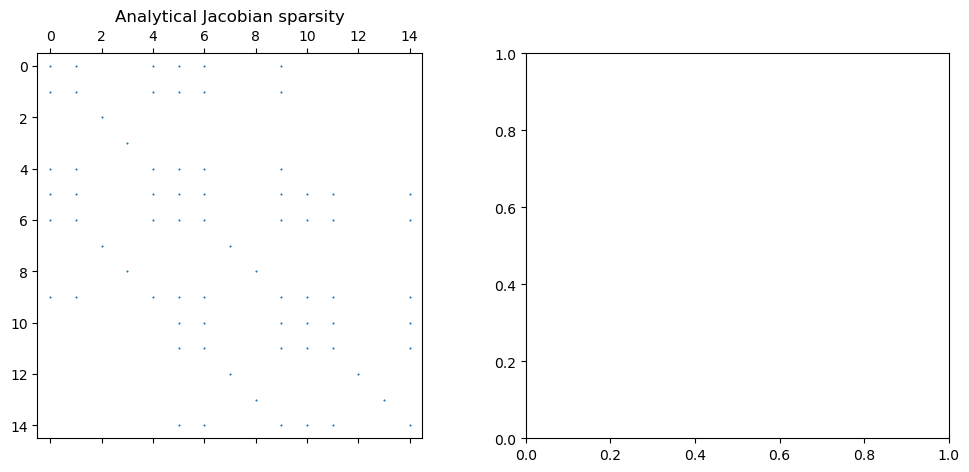

In [16]:
# sparsity pattern check 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#.spy to plot the sparsity pattern of a 2D array
axes[0].spy(global_jacobian, markersize=0.5)
axes[0].set_title('Analytical Jacobian sparsity')
plt.show()


4. Check by finite difference of vector multiplication 
J * q = (F(U+q*eps) -F(U))/eps

- randomly generate a vector q with shape (5N,)
- compute J * q 

- create a function that assemble the residual vector with shape (5N,)
- compute (F(U+q*eps) -F(U))/eps

- compare the two results

Errors at the boundary could be neglected --> it is a frozen ghost node problem 

Explaining the frozen ghost node problem
U_ghost = ghost_state(U_i, bc, ...), the ghost_node is a function of Ui

Frozen ghost node = Treat U_ghost as a constant (independent of Ui)

Such that: ∂F_bc/∂U_i ≈ A⁺(U_i, U_ghost, n)     ← frozen: ∂U_ghost/∂U_i = 0 as

But the true derivative: ∂F_bc/∂U_i = A⁺ + A⁻ @ ∂U_ghost/∂U_i    ← full chain rule

To make the Jacobian at boundaries exact :

def boundary_flux_jacobian_exact(U_i, bc, n_bc, gamma, R_gas, ...):
    U_g        = ghost_state(U_i, bc, n_bc, ...)
    dFi, dFj   = inviscid_flux_jacobians(U_i, U_g, n_bc, gamma)
    dU_ghost   = ghost_state_jacobian(U_i, bc, n_bc, ...)  # ∂U_ghost/∂U_i  (5×5)
    J_bc_exact = dFi + dFj @ dU_ghost                      # full chain rule
    return J_bc_exact

In [17]:
# ── Jacobian-vector product verification: J @ q ≈ (R(U + eps*q) - R(U)) / eps
# 1D 3-cell uniform flow test case
# ─────────────────────────────────────────────────────────────────────────────

gamma = 1.4
R_gas = 287.0

# ── 1D 3-cell setup ───────────────────────────────────────────────────────────
rho0 = 1.225
u0   = 100.0
p0   = 101325.0
E0   = p0 / ((gamma - 1) * rho0) + 0.5 * u0**2
U0   = np.array([rho0, rho0*u0, 0.0, 0.0, rho0*E0])

N      = 3
U_list = np.tile(U0, (N, 1))          # (3, 5) uniform flow
coord  = np.array([[0.0, 0.0, 0.0],
                   [1.0, 0.0, 0.0],
                   [2.0, 0.0, 0.0]])

# Interior faces: [i(1-based), j(1-based), Ax, Ay, Az]
fortfile_3cell = np.array([
    [1, 2,  1.0, 0.0, 0.0],
    [2, 3,  1.0, 0.0, 0.0],
])

# Boundary list: [node(1-based), Ax, Ay, Az, ds, bc_type, u_b, v_b, w_b, T_b, P_b, flag]
# bc_type   0=riemann | 1=slip | 2=noslip
T0_bc = p0 / (rho0 * R_gas)
boundary_list_3cell = np.array([
    [1,  -1.0, 0.0, 0.0, 1.0, 1, u0, 0.0, 0.0, T0_bc, p0, 1],   # left  → riemann
    [3,   1.0, 0.0, 0.0, 1.0, 1, u0, 0.0, 0.0, T0_bc, p0, 2],   # right → riemann
])

# ── Helper: assemble residual ─────────────────────────────────────────────────
def assemble_residual_1d(U_list, fortfile, boundary_list, gamma=1.4):
    N  = U_list.shape[0]
    R  = np.zeros((N, 5))
    bc_str = {0: 'riemann', 1: 'slip', 2: 'noslip'}

    for row in fortfile:
        i    = int(row[0]) - 1
        j    = int(row[1]) - 1
        A_ij = np.array([row[2], row[3], row[4]], dtype=float)
        Area = np.linalg.norm(A_ij)
        if Area < 1e-14: continue
        n_ij   = A_ij / Area
        F_L       = euler_flux(U_list[i], n_ij, gamma)
        F_R       = euler_flux(U_list[j], n_ij, gamma)
        U_roe = roe_average(U_list[i], U_list[j], gamma)
        abs_A_roe = absolute_normal_jacobian(U_roe, n_ij, gamma=gamma)
        F_face    = 0.5 * (F_L + F_R) - 0.5 * abs_A_roe @ (U_list[j] - U_list[i])
        R[i]  += F_face * Area
        R[j]  -= F_face * Area

    for row in boundary_list:
        i    = int(row[0]) - 1
        A_bc = np.array([row[1], row[2], row[3]], dtype=float)
        Area = np.linalg.norm(A_bc)
        if Area < 1e-14: continue
        n_bc = A_bc / Area
        bc   = bc_str[int(row[5])]
        u_b, v_b, w_b = float(row[6]), float(row[7]), float(row[8])
        T_b, P_b      = float(row[9]), float(row[10])
        U_g  = ghost_state(U_list[i], bc, n_bc, gamma, R_gas,
                           u_b, v_b, w_b, T_b, P_b)
        F_L   = euler_flux(U_list[i], n_bc, gamma)
        F_g   = euler_flux(U_g, n_bc, gamma)
        U_roe = roe_average(U_list[i], U_g, gamma)
        abs_A_roe = absolute_normal_jacobian(U_roe, n_bc, gamma=gamma)
        F_bc = 0.5 * (F_L + F_g) - 0.5 * abs_A_roe @ (U_g - U_list[i])
        R[i] += F_bc * Area

    return R.flatten()   # (5N,)



# ── Assemble analytical Jacobian ──────────────────────────────────────────────
J_anal = assemble_global_jacobian(
    fortfile_3cell, U_list, coord,
    boundary_list_3cell, gamma=gamma, R_gas=R_gas
)   # (15, 15)


# ── JV product check ──────────────────────────────────────────────────────────
eps    = 1e-6
np.random.seed(42)

# Fix 1 — fully random q of size (5N,), NOT tiled
q_full = np.random.randn(5 * N)

U_flat = U_list.flatten()

# base residual
R0 = assemble_residual_1d(U_list,
                           fortfile_3cell, boundary_list_3cell, gamma)

# FD Jacobian-vector product
R_pert  = assemble_residual_1d((U_flat + eps * q_full).reshape(-1, 5),
                                fortfile_3cell, boundary_list_3cell, gamma)
jv_fd   = (R_pert - R0) / eps

# analytical Jacobian-vector product
jv_anal = J_anal @ q_full

# ── Global error ──────────────────────────────────────────────────────────────
rel_err = np.linalg.norm(jv_fd - jv_anal) / (np.linalg.norm(jv_fd) + 1e-14)
print(f"JV product relative error (global): {rel_err:.4e}")

# ── Per-node breakdown ────────────────────────────────────────────────────────
print(f"\n{'Node':<6} {'type':<24} {'||jv_fd||':>12} {'||jv_anal||':>12} {'rel_err':>12}")
node_type = [f'BC left (bc type = {boundary_list_3cell[0,5]})', 'interior', f'BC right (bc type = {boundary_list_3cell[1,5]})']
for k in range(N):
    fd_k  = jv_fd  [5*k:5*k+5]
    an_k  = jv_anal[5*k:5*k+5]
    err_k = np.linalg.norm(fd_k - an_k) / (np.linalg.norm(fd_k) + 1e-14)
    print(f"{k:<6} {node_type[k]:<24} "
          f"{np.linalg.norm(fd_k):>12.4e} "
          f"{np.linalg.norm(an_k):>12.4e} "
          f"{err_k:>12.4e}")

# ── Interior-only error (excludes frozen ghost effect at boundaries) ───────────
interior_idx = np.arange(5, 10)   # node 1 only → DOFs 5..9
rel_err_int  = (np.linalg.norm(jv_fd[interior_idx] - jv_anal[interior_idx])
                / (np.linalg.norm(jv_fd[interior_idx]) + 1e-14))
print(f"\nInterior-only relative error: {rel_err_int:.4e}   ← main check")

NameError: name 'assemble_global_jacobian' is not defined